<a href="https://colab.research.google.com/github/Prajnaa002/Applied_Machine_Learning/blob/main/AML_DataPreprocessing_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SOCIAL NETWORK ADS DATASET

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data= pd.read_csv("drive/My Drive/Colab Notebooks/Datasets/Social_Network_Ads.csv")
dataset= data # loading data
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
X = dataset.iloc[:, [2, 3]].values #independent variable
y = dataset.iloc[:, 4].values#dependant variable

In [ ]:
#check for null values
dataset.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling and Preprocessed Data

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test

array([[-0.80480212,  0.50496393],
       [-0.01254409, -0.5677824 ],
       [-0.30964085,  0.1570462 ],
       [-0.80480212,  0.27301877],
       [-0.30964085, -0.5677824 ],
       [-1.10189888, -1.43757673],
       [-0.70576986, -1.58254245],
       [-0.21060859,  2.15757314],
       [-1.99318916, -0.04590581],
       [ 0.8787462 , -0.77073441],
       [-0.80480212, -0.59677555],
       [-1.00286662, -0.42281668],
       [-0.11157634, -0.42281668],
       [ 0.08648817,  0.21503249],
       [-1.79512465,  0.47597078],
       [-0.60673761,  1.37475825],
       [-0.11157634,  0.21503249],
       [-1.89415691,  0.44697764],
       [ 1.67100423,  1.75166912],
       [-0.30964085, -1.37959044],
       [-0.30964085, -0.65476184],
       [ 0.8787462 ,  2.15757314],
       [ 0.28455268, -0.53878926],
       [ 0.8787462 ,  1.02684052],
       [-1.49802789, -1.20563157],
       [ 1.07681071,  2.07059371],
       [-1.00286662,  0.50496393],
       [-0.90383437,  0.30201192],
       [-0.11157634,

In [ ]:
# print('Scaled X_train:')
# display(X_train[:5])
# print('\nScaled X_test:')
# display(X_test[:5])

#Fitting decision tree classification  to the training set

In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
#classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
#classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)


#predicting the test set results

In [ ]:
y_pred = classifier.predict(X_test)
y_pred #PREDICTED VALUE

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

In [ ]:
y_test #ACTUAL VALUE

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

Making the confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[62,  6],
       [ 4, 28]])

In [ ]:
Accuracy = (cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+cm[1][1])
Accuracy

np.float64(0.9)

In [ ]:
from sklearn import metrics
#model accuracy: how often is the classifier correct?
prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ", prediction * 100, "%")

Accuracy:  90.0 %


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.91      0.93        68
           1       0.82      0.88      0.85        32

    accuracy                           0.90       100
   macro avg       0.88      0.89      0.89       100
weighted avg       0.90      0.90      0.90       100



In [ ]:
#predict for a new individual with age = 29 and estimated slary = 80000
new_individual = np.array([[29,80000]])

#scale the new individual's features
new_individual_scaled = sc.transform(new_individual)

#predict using the trained classifier
prediction = classifier.predict(new_individual_scaled)

if prediction[0] == 1:
  print("The individual is predicted to purchase the product")
else:
  print("The individual is not predicted to purchase the product")


The individual is not predicted to purchase the product


[Text(0.4519230769230769, 0.9615384615384616, 'x[0] <= 0.631\ngini = 0.466\nsamples = 300\nvalue = [189, 111]'),
 Text(0.22435897435897437, 0.8846153846153846, 'x[1] <= 0.606\ngini = 0.303\nsamples = 215\nvalue = [175, 40]'),
 Text(0.33814102564102566, 0.9230769230769231, 'True  '),
 Text(0.11538461538461539, 0.8076923076923077, 'x[0] <= -0.161\ngini = 0.076\nsamples = 176\nvalue = [169, 7]'),
 Text(0.08974358974358974, 0.7307692307692307, 'gini = 0.0\nsamples = 114\nvalue = [114, 0]'),
 Text(0.14102564102564102, 0.7307692307692307, 'x[1] <= 0.403\ngini = 0.2\nsamples = 62\nvalue = [55, 7]'),
 Text(0.11538461538461539, 0.6538461538461539, 'x[1] <= -0.06\ngini = 0.153\nsamples = 60\nvalue = [55, 5]'),
 Text(0.08974358974358974, 0.5769230769230769, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.14102564102564102, 0.5769230769230769, 'x[1] <= 0.027\ngini = 0.285\nsamples = 29\nvalue = [24, 5]'),
 Text(0.11538461538461539, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.166

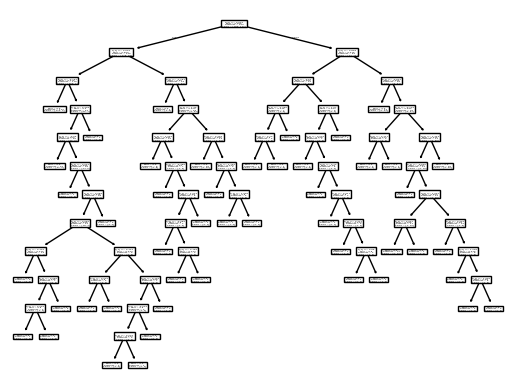

In [ ]:
from sklearn import tree
tree.plot_tree(classifier)

DIABETES DATASET

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data= pd.read_csv("drive/My Drive/Colab Notebooks/Datasets/diabetes.csv")
dataset= data # loading data
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
X = dataset.iloc[:, :-1].values #independent variable
y = dataset.iloc[:, -1].values#dependant variable

In [ ]:
#check for null values
dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test

array([[-0.82986389,  2.4576282 ,  0.33249916, ...,  1.34420526,
         2.78665365, -0.96584853],
       [-0.53768687, -0.44693118,  0.2272108 , ...,  0.17490974,
        -0.19434743, -0.88246592],
       [ 0.04666716, -1.42564141, -0.40451932, ...,  0.22520202,
        -0.23349189, -0.71570071],
       ...,
       [-0.82986389, -0.38378859, -0.50980767, ..., -0.85608201,
         1.4406865 , -1.04923114],
       [-0.24550986,  0.21606607,  0.43778751, ..., -1.39672402,
        -0.60385869,  1.7857775 ],
       [ 0.33884418, -1.04678584,  0.43778751, ..., -0.57947447,
        -0.63396981,  0.28489057]])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
#classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
#classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)
y_pred #PREDICTED VALUE

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0])

In [ ]:
y_test #ACTUAL VALUE

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0])

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[101,  29],
       [ 26,  36]])

In [ ]:
Accuracy = (cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+cm[1][1])
Accuracy

np.float64(0.7135416666666666)

In [ ]:
from sklearn import metrics
#model accuracy: how often is the classifier correct?
prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ", prediction * 100, "%")

Accuracy:  71.35416666666666 %


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.78      0.79       130
           1       0.55      0.58      0.57        62

    accuracy                           0.71       192
   macro avg       0.67      0.68      0.68       192
weighted avg       0.72      0.71      0.72       192



In [ ]:
# Predict for a new individual with specific characteristics for the diabetes dataset
new_individual_diabetes = np.array([[2, 120, 70, 30, 100, 25, 0.5, 35]])

# Scale the new individual's features using the StandardScaler fitted on the diabetes dataset
new_individual_diabetes_scaled = sc.transform(new_individual_diabetes)

# Predict using the trained classifier (which was trained on the diabetes dataset)
prediction_diabetes = classifier.predict(new_individual_diabetes_scaled)

if prediction_diabetes[0] == 1:
  print("The individual is predicted to have diabetes.")
else:
  print("The individual is predicted NOT to have diabetes.")

The individual is predicted NOT to have diabetes.


[Text(0.5491563360881543, 0.9705882352941176, 'x[1] <= 0.737\ngini = 0.459\nsamples = 576\nvalue = [370, 206]'),
 Text(0.2277892561983471, 0.9117647058823529, 'x[7] <= -0.424\ngini = 0.372\nsamples = 445\nvalue = [335, 110]'),
 Text(0.3884727961432507, 0.9411764705882353, 'True  '),
 Text(0.09228650137741047, 0.8529411764705882, 'x[5] <= -0.221\ngini = 0.21\nsamples = 235\nvalue = [207, 28]'),
 Text(0.03305785123966942, 0.7941176470588235, 'x[0] <= 0.923\ngini = 0.035\nsamples = 113\nvalue = [111, 2]'),
 Text(0.02203856749311295, 0.7352941176470589, 'x[6] <= 0.613\ngini = 0.018\nsamples = 112\nvalue = [111, 1]'),
 Text(0.011019283746556474, 0.6764705882352942, 'gini = 0.0\nsamples = 99\nvalue = [99, 0]'),
 Text(0.03305785123966942, 0.6764705882352942, 'x[3] <= -0.476\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.02203856749311295, 0.6176470588235294, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.0440771349862259, 0.6176470588235294, 'gini = 0.0\nsamples = 12\nvalue = [1

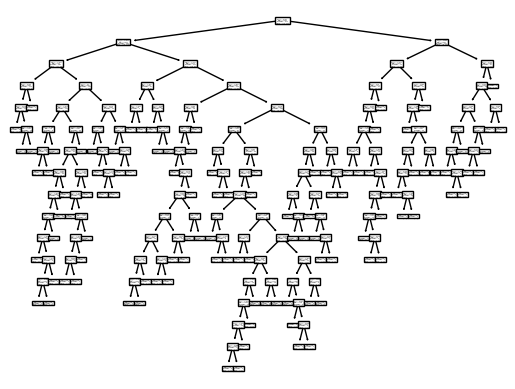

In [ ]:
from sklearn import tree
tree.plot_tree(classifier)

IRIS DATASET

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data= pd.read_csv("drive/My Drive/Colab Notebooks/Datasets/Iris.csv")
dataset= data # loading data
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [ ]:
X = dataset.iloc[:, 1:5].values #independent variable
y = dataset.iloc[:, 5].values#dependant variable

In [ ]:
#check for null values
dataset.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test

array([[-0.09984503, -0.57982483,  0.72717965,  1.51147115],
       [ 0.13072494, -1.96153508,  0.11355956, -0.28533458],
       [-0.44569998,  2.64416573, -1.33681519, -1.31208072],
       [ 1.62942973, -0.34953979,  1.39658338,  0.74141155],
       [-1.0221249 ,  0.80188541, -1.28103155, -1.31208072],
       [ 0.47657989,  0.57160037,  1.22923245,  1.63981441],
       [-1.0221249 ,  1.03217045, -1.39259884, -1.18373745],
       [ 0.93771983,  0.11103029,  0.50404507,  0.35638175],
       [ 1.05300481, -0.57982483,  0.55982872,  0.22803848],
       [ 0.24600992, -0.57982483,  0.11355956,  0.09969522],
       [ 0.24600992, -1.04039491,  1.00609787,  0.22803848],
       [ 0.59186487,  0.34131533,  0.39247778,  0.35638175],
       [ 0.24600992, -0.57982483,  0.50404507, -0.02864805],
       [ 0.70714986, -0.57982483,  0.44826143,  0.35638175],
       [ 0.24600992, -0.34953979,  0.50404507,  0.22803848],
       [-1.13740989,  0.11103029, -1.28103155, -1.44042398],
       [ 0.13072494, -0.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
#classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
#classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)
y_pred #PREDICTED VALUE

array([2, 0, 1, 2, 1, 2, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 0, 1, 2])

In [ ]:
y_test #ACTUAL VALUE

array([2, 0, 1, 2, 1, 2, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 0, 1, 0])

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[15,  0,  1],
       [ 0, 13,  0],
       [ 0,  0,  9]])

In [ ]:
Accuracy = (cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+cm[1][1])
Accuracy

np.float64(1.0)

In [ ]:
from sklearn import metrics
#model accuracy: how often is the classifier correct?
prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ", prediction * 100, "%")

Accuracy:  97.36842105263158 %


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       1.00      1.00      1.00        13
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



In [ ]:
# Example for a new individual: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
# Let's say a new flower has these measurements:
new_individual = np.array([[5.5, 2.5, 4.0, 1.3]]) # Example values

# Scale the new individual's features using the same scaler fitted on the training data
new_individual_scaled = sc.transform(new_individual)

# Make a prediction with the trained classifier
prediction = classifier.predict(new_individual_scaled)

# Decode the predicted class (assuming 0, 1, 2 correspond to Iris-setosa, Iris-versicolor, Iris-virginica)
# You might need to map these back to original species names if you used LabelEncoder earlier
if prediction[0] == 0:
    print("Predicted Species: Iris-setosa")
elif prediction[0] == 1:
    print("Predicted Species: Iris-versicolor")
elif prediction[0] == 2:
    print("Predicted Species: Iris-virginica")
else:
    print(f"Predicted class: {prediction[0]}")

Predicted Species: Iris-setosa


[Text(0.4, 0.9, 'x[3] <= -0.542\ngini = 0.665\nsamples = 112\nvalue = [34, 37, 41]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 37\nvalue = [0, 37, 0]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[2] <= 0.644\ngini = 0.496\nsamples = 75\nvalue = [34, 0, 41]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'x[3] <= 0.549\ngini = 0.153\nsamples = 36\nvalue = [33, 0, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 32\nvalue = [32, 0, 0]'),
 Text(0.3, 0.3, 'x[1] <= 0.111\ngini = 0.375\nsamples = 4\nvalue = [1, 0, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.8, 0.5, 'x[3] <= 0.677\ngini = 0.05\nsamples = 39\nvalue = [1, 0, 38]'),
 Text(0.7, 0.3, 'x[3] <= 0.549\ngini = 0.375\nsamples = 4\nvalue = [1, 0, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 35\nvalue = [0, 0, 35]')]

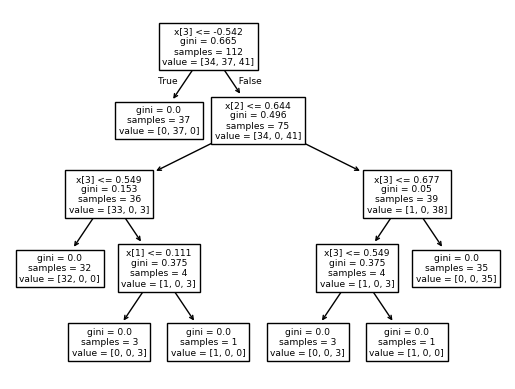

In [ ]:
from sklearn import tree
tree.plot_tree(classifier)